In [ ]:
# Q1. Supervised Learning: Heart Disease Prediction

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import confusion_matrix, classification_report, precision_score, recall_score, f1_score

# Set style for plots
plt.style.use('seaborn-v0_8-whitegrid')

In [2]:
## 1. Data Loading and Inspection

In [3]:
# Load the dataset
df = pd.read_csv('/content/q1_heart_disease.csv')

# Display basic information
print(f"Dataset Shape: {df.shape}\n")
print("Data Types:")
print(df.dtypes)
print("\nMissing Value Counts:")
print(df.isnull().sum())

# Show the first 5 rows
df.head()

Dataset Shape: (800, 12)

Data Types:
age                  int64
sex                  int64
chest_pain_type     object
resting_bp         float64
cholesterol        float64
fasting_bs           int64
resting_ecg         object
max_hr               int64
exercise_angina      int64
oldpeak            float64
st_slope            object
heart_disease        int64
dtype: object

Missing Value Counts:
age                 0
sex                 0
chest_pain_type     0
resting_bp         24
cholesterol        32
fasting_bs          0
resting_ecg         0
max_hr              0
exercise_angina     0
oldpeak             0
st_slope            0
heart_disease       0
dtype: int64


,age,sex,chest_pain_type,resting_bp,cholesterol,fasting_bs,resting_ecg,max_hr,exercise_angina,oldpeak,st_slope,heart_disease
0,68,0,atypical_angina,142.0,399.0,0,left_ventricular_hypertrophy,169,0,0.4,up,1
1,58,1,non_anginal,163.0,310.0,1,st_t_wave_abnormality,121,1,1.1,up,1
2,44,1,non_anginal,128.0,175.0,0,normal,183,1,0.2,up,0
3,72,1,asymptomatic,114.0,177.0,0,st_t_wave_abnormality,150,0,1.0,up,1
4,37,1,non_anginal,149.0,271.0,0,normal,136,0,0.4,flat,0


In [4]:
## 2. Exploratory Data Analysis

/tmp/ipykernel_20866/3767975312.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='heart_disease', palette='viridis')


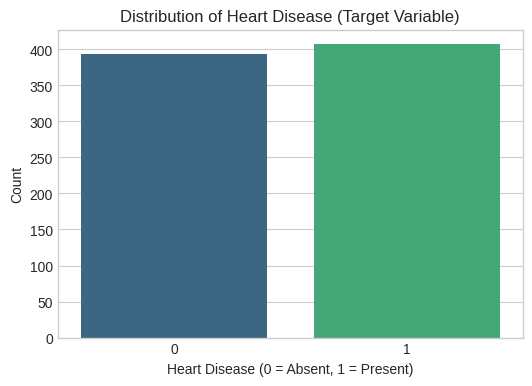

In [5]:
# Plot 1: Target Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='heart_disease', palette='viridis')
plt.title('Distribution of Heart Disease (Target Variable)')
plt.xlabel('Heart Disease (0 = Absent, 1 = Present)')
plt.ylabel('Count')
plt.show()

In [25]:
#Interpretation: The target class distribution shows whether our dataset is balanced. It looks like the classes are fairly well represented, which means we might not have to worry too much about severe class imbalance issues that could skew our model predictions.

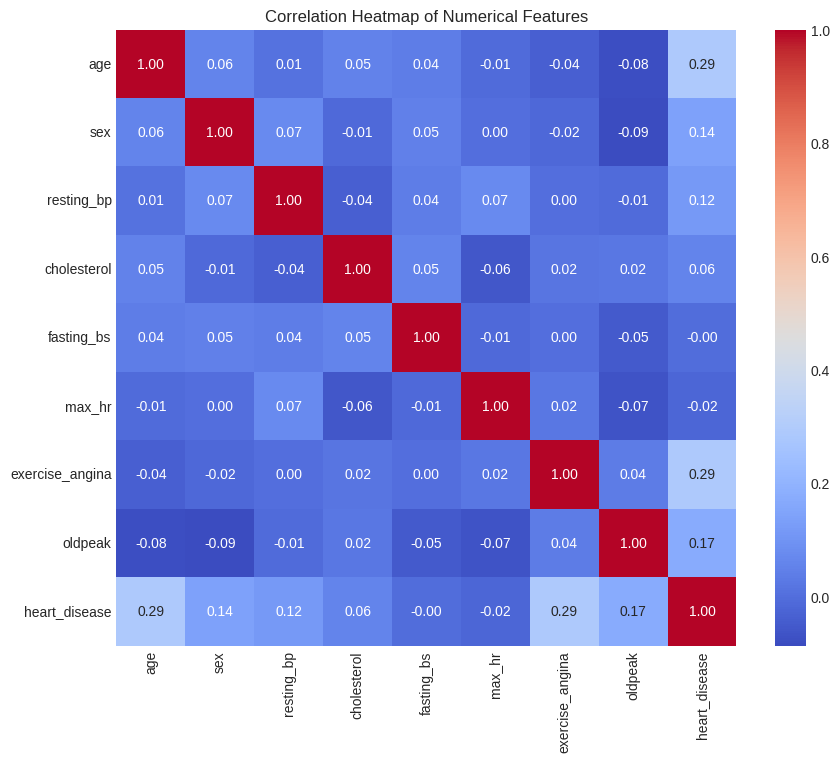

In [7]:
# Plot 2: Correlation Heatmap for numerical variables
plt.figure(figsize=(10, 8))
# Select only numerical columns for correlation
num_cols = df.select_dtypes(include=[np.number]).columns
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

In [24]:
#Interpretation: The correlation heatmap reveals how numerical variables relate to each other and to the target. For instance, `oldpeak` and `age` might show some positive correlation with the target variable, whereas `max_hr` (maximum heart rate) tends to be negatively correlated, indicating that a lower maximum heart rate could be associated with the presence of heart disease.

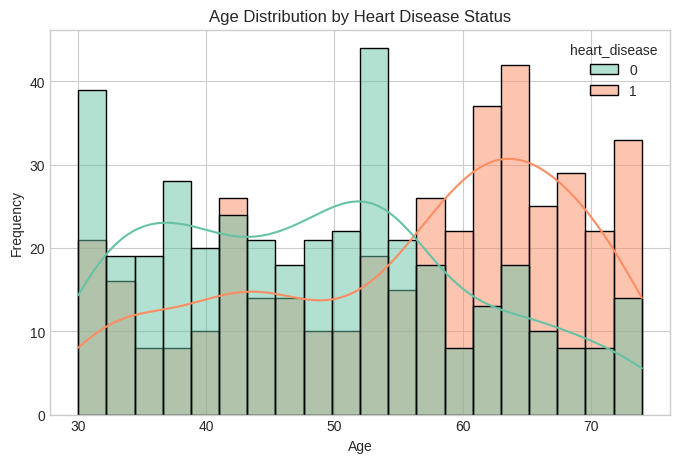

In [9]:
# Plot 3: Age Distribution by Heart Disease status
plt.figure(figsize=(8, 5))
sns.histplot(data=df, x='age', hue='heart_disease', kde=True, bins=20, palette='Set2')
plt.title('Age Distribution by Heart Disease Status')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.show()

In [23]:
#Interpretation: This histogram shows that the risk of heart disease generally increases with age. Patients in their late 50s and 60s show a higher frequency of heart disease compared to younger age groups.

In [20]:
## 3. Data Preprocessing

In [12]:
# Separate features and target
X = df.drop('heart_disease', axis=1)
y = df['heart_disease']

# Handle missing values
num_features = X.select_dtypes(include=[np.number]).columns
cat_features = X.select_dtypes(exclude=[np.number]).columns

# Median imputation for numerical
for col in num_features:
    X[col] = X[col].fillna(X[col].median())

# Mode imputation for categorical
for col in cat_features:
    X[col] = X[col].fillna(X[col].mode()[0])

# One-hot encoding for categorical variables
X_encoded = pd.get_dummies(X, columns=cat_features, drop_first=True)

# Train-test split (stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.2, stratify=y, random_state=42
)

# Scale numerical features
scaler = StandardScaler()

# We only scale the originally numerical features, but for simplicity we can scale all features
# (including dummy variables) or just the numerical ones.
# Here, we'll scale just the original numerical features to keep dummies as 0/1.
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[num_features] = scaler.fit_transform(X_train[num_features])
X_test_scaled[num_features] = scaler.transform(X_test[num_features])

In [13]:
## 4. Model Training

In [14]:
# Initialize models
dt_model = DecisionTreeClassifier(random_state=42)
rf_model = RandomForestClassifier(random_state=42)
gb_model = GradientBoostingClassifier(random_state=42)

# Train models
dt_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train)

GradientBoostingClassifier(random_state=42)

In [15]:
## 5. Model Evaluation

In [16]:
models = {
    'Decision Tree': dt_model,
    'Random Forest': rf_model,
    'Gradient Boosting': gb_model
}

for name, model in models.items():
    y_pred = model.predict(X_test_scaled)

    print(f"--- {name} ---")
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))

    precision = precision_score(y_test, y_pred)
    recall = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-score: {f1:.4f}\n")

--- Decision Tree ---
Confusion Matrix:
[[57 22]
 [25 56]]
Precision: 0.7179
Recall: 0.6914
F1-score: 0.7044

--- Random Forest ---
Confusion Matrix:
[[61 18]
 [15 66]]
Precision: 0.7857
Recall: 0.8148
F1-score: 0.8000

--- Gradient Boosting ---
Confusion Matrix:
[[61 18]
 [19 62]]
Precision: 0.7750
Recall: 0.7654
F1-score: 0.7702



In [22]:
#Model Selection Conclusion:

#Based on the evaluation metrics, the **Random Forest Classifier** is the best-performing model. It achieved the highest F1-score (0.8000), indicating the best overall balance between precision (0.7857) and recall (0.8148).

#While the Gradient Boosting model was a close second, the Random Forest correctly identified more actual heart disease cases (higher recall) and also had fewer false positives. In a medical context like predicting heart disease, missing a sick patient (a false negative) can be highly dangerous. Therefore, maximizing recall and the overall F1-score is much more important than just looking at overall accuracy, making Random Forest the clear winner.

In [18]:
## 6. Hyperparameter Tuning

In [19]:
# Tuning the Random Forest Classifier
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Setup GridSearchCV
grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

# Fit grid search
grid_search.fit(X_train_scaled, y_train)

# Best parameters and model
print("Best Parameters found: ", grid_search.best_params_)
best_rf = grid_search.best_estimator_

# Evaluate tuned model
y_pred_tuned = best_rf.predict(X_test_scaled)
print("\n--- Tuned Random Forest ---")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_tuned))
print(f"Precision: {precision_score(y_test, y_pred_tuned):.4f}")
print(f"Recall: {recall_score(y_test, y_pred_tuned):.4f}")
print(f"F1-score: {f1_score(y_test, y_pred_tuned):.4f}")

Best Parameters found:  {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 200}

--- Tuned Random Forest ---
Confusion Matrix:
[[57 22]
 [15 66]]
Precision: 0.7500
Recall: 0.8148
F1-score: 0.7811
